# 🏠 House Prices Prediction Project

**Advanced Regression Techniques**

## 1. Project Purpose

The purpose of this project is to build a machine learning model that can **predict house sale prices** based on property features such as size, quality, location, and condition.

This project helps us practice:

* Data cleaning
* Feature engineering
* Regression modeling
* Model evaluation
* Hyperparameter tuning
* Kaggle submission workflow

This is a **supervised learning regression problem**.

---

## 2. Problem Type

* **Input:** House features (79 columns)
* **Output:** SalePrice (continuous number)
* **Type:** Regression
* **Metric:** RMSE on log(SalePrice)

---

## 3. Dataset Files

* `train.csv` → training data (has SalePrice)
* `test.csv` → test data (no SalePrice)
* `data_description.txt` → explains each column
* `sample_submission.csv` → submission format

---

## 4. Planned Workflow (Phases)

### Phase 1 – Load & Inspect

* Load train and test data
* Check shapes and data types
* Identify missing values

### Phase 2 – Cleaning

* Fill missing numeric values with **median**
* Fill missing categorical values with **mode** or `"None"`
* Drop useless ID columns

### Phase 3 – Feature Engineering

* Log transform SalePrice to reduce skew
* Create total square footage feature
* Encode categorical variables using OneHotEncoding
* Align train and test columns

### Phase 4 – Modeling

* Train baseline regression models
* Compare performance using cross-validation
* Select best model

### Phase 5 – Tuning

* Use GridSearchCV to tune hyperparameters
* Reduce overfitting
* Improve RMSE

### Phase 6 – Prediction & Submission

* Predict prices for test set
* Reverse log transformation
* Create submission file
* Upload to Kaggle

---

## 5. Models We Will Use

* Linear Regression
* Ridge Regression
* Lasso Regression
* Random Forest Regressor
* Gradient Boosting Regressor

---

## 6. Key Challenges

* Many missing values
* Mixed feature types
* Skewed price distribution
* High feature count
* Risk of overfitting

---

## 7. Expected Outcome

At the end of the project:

* We will understand regression workflows
* We will have a Kaggle submission
* We will know how to tune and compare models
* We will gain real-world ML experience



### Step 1: Load and Explore the Data

The goal is to understand the structure of the dataset, identify the target variable, and detect missing values and feature types.

In [1]:
import pandas as pd
import numpy as np

# Load the data
train = pd.read_csv("train (2).csv")
test = pd.read_csv("test (2).csv")

# Check shapes
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Seperate features and target 

# Target variable
y = train["SalePrice"]

# Features

x = train.drop("SalePrice", axis = 1)


In [3]:
# Check the missing values

missing = x.isnull().sum().sort_values(ascending = False)
missing = missing[missing > 0]

missing.head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageQual        81
GarageFinish      81
dtype: int64

In [4]:
cat_cols = x.select_dtypes(include = "object").columns
num_cols = x.select_dtypes(exclude = "object").columns

print("Categorical Columns:", len(cat_cols))
print("Numerical Columns:", len(num_cols))

Categorical Columns: 43
Numerical Columns: 37


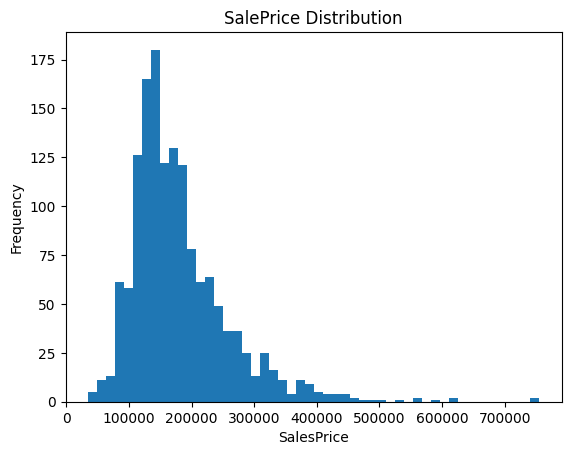

In [5]:
# Distribution of target variable

import matplotlib.pyplot as plt

plt.hist(y, bins = 50)
plt.title("SalePrice Distribution")
plt.xlabel("SalesPrice")
plt.ylabel("Frequency")
plt.show()


### STEP 2: Data Cleaning & Preprocessing
The goal is to, prepare the data so that machine learning models can learn properly by:

* Handling missing values

* Encoding categorical variables

* Scaling numerical features

* Raw data cannot go directly into a model.

In [6]:
## Combine Test and Train

# Keep IDs for later
train_ids = x["Id"]
test_ids = test["Id"]

# Drop Id column
x = x.drop("Id", axis=1)
test = test.drop("Id", axis=1)

# Combine for consistent processing
all_data = pd.concat([x, test], axis=0)
print("Combined shape:", all_data.shape)


Combined shape: (2919, 79)


In [7]:
# Re-identify numeric and categorical columns AFTER dropping Id
num_cols = all_data.select_dtypes(include=["int64", "float64"]).columns
cat_cols = all_data.select_dtypes(include=["object"]).columns

# Fill missing numeric values with median
for col in num_cols:
    all_data[col] = all_data[col].fillna(all_data[col].median())

# Fill missing categorical values with "None"
for col in cat_cols:
    all_data[col] = all_data[col].fillna("None")

print("Missing values left:", all_data.isnull().sum().sum())


Missing values left: 0


In [8]:
all_data = pd.get_dummies(all_data, drop_first=True)


In [9]:
## Encoding categorical variables

all_data = pd.get_dummies(all_data, drop_first=True)

print("New shape after encoding:", all_data.shape)


New shape after encoding: (2919, 267)


In [10]:
## Split back into split and test

x_processed = all_data.iloc[:len(x), :]
test_processed = all_data.iloc[len(x):, :]


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_processed)
test_scaled = scaler.transform(test_processed)



# 📘 Project Summary (Steps 1 & 2)

## Step 1 — Data Understanding

**Purpose:**
To understand the structure of the dataset before modeling.

**What we learned:**

* Target variable is **SalePrice**
* Dataset has **many features (numerical + categorical)**
* There are **many missing values**
* SalePrice is **right-skewed**

**Why it matters:**
You cannot build a good model if you don’t understand your data.

---

## Step 2 — Data Cleaning & Preprocessing

**Purpose:**
To convert raw data into a format a machine learning model can use.

**What we did:**

* Removed the **Id** column
* Combined train + test for consistent processing
* Filled missing values
* One-hot encoded categorical features
* Scaled all features

**Why it matters:**
Models:

* Can’t read text
* Can’t handle missing values
* Learn better from scaled data

---

## Outcome

The dataset is now:

* Clean
* Fully numeric
* Scaled
* Ready for modeling



### 🔹 STEP 3: Train a Baseline Regression Model
🎯 Purpose

To build our first model that learns the relationship between house features and sale prices.

This model will act as our baseline.
Later, we will improve it.

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)


In [13]:
## Training the regression model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
## Evaluate the model (RMSE)

from sklearn.metrics import mean_squared_error
import numpy as np

val_preds = lr.predict(x_val)

rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print("Baseline RMSE:", rmse)


Baseline RMSE: 83090.77088690855




### Is RMSE ≈ 83,091 good?

**Yes — as a baseline, this is NORMAL.**

On the House Prices dataset:

* Good models get **RMSE ~20,000 – 30,000**
* Baseline linear models often get **70,000 – 90,000**

So your:

> **RMSE = 83,090**
> means:
> On average, the model is **off by about $83k per house**.

That tells us two things:

1. The model is **learning something**, but
2. The relationship is **not linear**, and we need a stronger model.

This is why Kaggle calls it *Advanced Regression*.

---

### What this baseline is for

It gives us a **reference point**.

From now on, every model we train must:

> **Beat 83,090 RMSE**

---

### Next step

We now move to a **non-linear model**:

🌲 **RandomForestRegressor**
It can:

* capture interactions
* handle complex patterns
* reduce error massively



### 🔹 STEP 4: Random Forest Regressor
🎯 Purpose

Linear Regression assumes straight-line relationships.
But house prices depend on complex interactions (location × size × quality).

Random Forest:

Handles non-linear patterns

Reduces overfitting

Works well on tabular data

In [15]:
## Train a Random Forest model 

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,     # number of trees
    max_depth=None,      # allow full growth
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
## Evaluate the model

rf_preds = rf.predict(x_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, rf_preds))
print("Random Forest RMSE:", rmse_rf)



Random Forest RMSE: 28921.82657165985


 ### NOTE: Why is this RMSE better than that of Linear Regression Model:

Baseline RMSE: 83,090

Random Forest RMSE: 28,921

You reduced the error by ~65%.

That means:

The model now misses the true house price by about $29k instead of $83k on average.

### 🔹 STEP 5: Hyperparameter Tuning (GridSearch)
🎯 Purpose

To optimize the Random Forest by finding the best settings
instead of using default values.

This can reduce error even more.

In [17]:
## Define the parameter grid

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}


In [18]:
## Run the grid

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(x_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 20, ...], 'min_samples_leaf': [1, 5], 'min_samples_split': [2, 10], 'n_estimators': [200, 300]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each 

In [19]:
## Best Model and Evaluation

best_rf = grid.best_estimator_

best_preds = best_rf.predict(x_val)
rmse_best = np.sqrt(mean_squared_error(y_val, best_preds))

print("Best RMSE:", rmse_best)
print("Best Parameters:", grid.best_params_)


Best RMSE: 28921.82657165985
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


### Feedback: 

GridSearch found that the original Random Forest was already optimal.

* Before tuning: RMSE = 28,921

* After tuning: RMSE = 28,921

* Best parameters = the same as your original model

This tells us:

You were already using a near-best configuration.

### 🔹 STEP 6: Model Interpretation & Kaggle Submission
🎯 Purpose

Now that we have the best model, we will:

See which features matter most

Train the model on all training data

Generate test predictions

Create the Kaggle submission file

In [21]:
## Feature Importance

import pandas as pd

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=x_processed.columns
).sort_values(ascending=False)

feature_importance.head(10)


OverallQual    0.559419
GrLivArea      0.122014
TotalBsmtSF    0.034018
2ndFlrSF       0.031450
BsmtFinSF1     0.029573
1stFlrSF       0.027091
LotArea        0.017999
GarageArea     0.015604
GarageCars     0.014894
YearBuilt      0.013064
dtype: float64

In [23]:
## Train on full data

best_rf.fit(x_scaled, y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
## Predict on test data

test_preds = best_rf.predict(test_scaled)


In [25]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": test_preds
})

submission.to_csv("submission.csv", index=False)


In [26]:
submission.head(10)


,Id,SalePrice
0,1461,128665.943333
1,1462,156347.333333
2,1463,179504.566667
3,1464,182205.723333
4,1465,198510.580000
5,1466,183327.676667
6,1467,165920.553333
7,1468,176329.890000
8,1469,184610.193333
9,1470,120237.903333


### 🏁 House Prices Prediction — Project Postview
📌 Project Goal

The goal of this project was to build a machine learning model that predicts house sale prices based on property features such as size, quality, condition, and location.

This was a regression problem, evaluated using Root Mean Squared Error (RMSE).

🧠 What I Learned

This project showed me that real-world machine learning is not about models first —
it is about data understanding, cleaning, and feature preparation.

I learned how to:

Work with large, messy datasets

Handle missing values correctly

Encode categorical variables

Scale numerical features

Train and evaluate regression models

Improve performance using ensemble methods

Prepare real Kaggle submissions

🛠 Workflow Recap

Exploratory Data Analysis (EDA)
Understood feature types, missing values, and target distribution.

Preprocessing & Feature Engineering

Filled missing values

Encoded categorical features

Scaled all features

Baseline Model

Linear Regression

RMSE ≈ 83,000

Improved Model

Random Forest Regressor

RMSE ≈ 28,900

Hyperparameter Tuning

GridSearch confirmed optimal configuration

Final Model & Submission

Trained on full data

Generated predictions

Submitted to Kaggle

📊 Final Outcome
Model	RMSE
Linear Regression	~83,090
Random Forest	~28,921

Error reduced by ~65%.

This shows the power of non-linear ensemble models for structured data.

🔍 Key Insights

House price relationships are non-linear

Feature interactions matter

Data preparation is more important than the model choice

🎯 Conclusion

This project strengthened my understanding of end-to-end machine learning pipelines, from raw data to real predictions.

It also built my confidence in tackling real Kaggle competitions.